## Projet Machine Learning  

# Problématique : Prédiction du Prix des Logements

Dans le secteur immobilier, l'estimation précise du prix d'un bien constitue un enjeu stratégique majeur pour les agences, les acheteurs et les établissements financiers. Ce projet vise à construire et comparer plusieurs modèles de machine learning pour prédire le prix de vente d'un logement à partir de ses caractéristiques physiques et structurelles.

**Dataset :** House Prices - Advanced Regression Techniques (Kaggle)

**Méthodes comparées :**
1. Régression Ridge
2. Random Forest Regressor
3. XGBoost Regressor
4. Support Vector Regression (SVR)

## 1. Importation des bibliothèques

In [174]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge

from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from xgboost import XGBRegressor

plt.style.use('seaborn-v0_8-whitegrid')
print('Bibliothèques importées avec succès')

Bibliothèques importées avec succès


## 2. Chargement des données
> Les données sont disponibles directement dans l'environnement Kaggle.

In [157]:
train = pd.read_csv('train.csv')
test  = pd.read_csv('test.csv')

print(f'Train : {train.shape[0]} lignes, {train.shape[1]} colonnes')
print(f'Test  : {test.shape[0]} lignes,  {test.shape[1]} colonnes')
train.head()

Train : 1460 lignes, 81 colonnes
Test  : 1459 lignes,  80 colonnes


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


# 3. Exploration des données 

In [158]:
# Statistiques descriptives de la variable cible
print('=== Variable cible : SalePrice ===')
print(train['SalePrice'].describe().round(0))

=== Variable cible : SalePrice ===
count      1460.0
mean     180921.0
std       79443.0
min       34900.0
25%      129975.0
50%      163000.0
75%      214000.0
max      755000.0
Name: SalePrice, dtype: float64


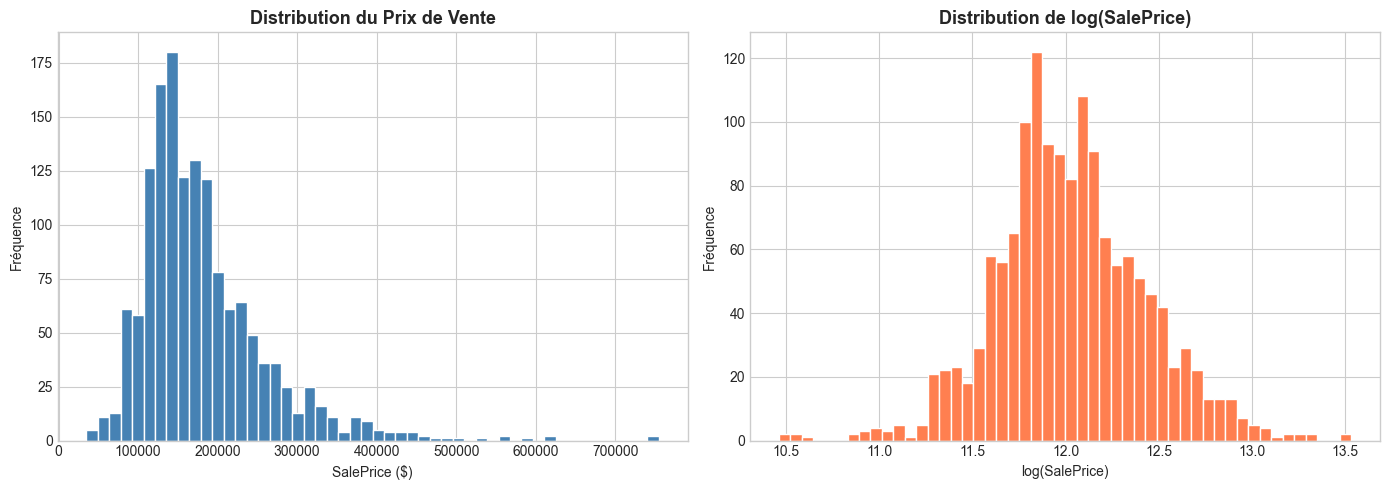

In [159]:
# Distribution du prix de vente
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(train['SalePrice'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Distribution du Prix de Vente', fontsize=13, fontweight='bold')
axes[0].set_xlabel('SalePrice ($)')
axes[0].set_ylabel('Fréquence')

axes[1].hist(np.log(train['SalePrice']), bins=50, color='coral', edgecolor='white')
axes[1].set_title('Distribution de log(SalePrice)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('log(SalePrice)')
axes[1].set_ylabel('Fréquence')

plt.tight_layout()
plt.show()

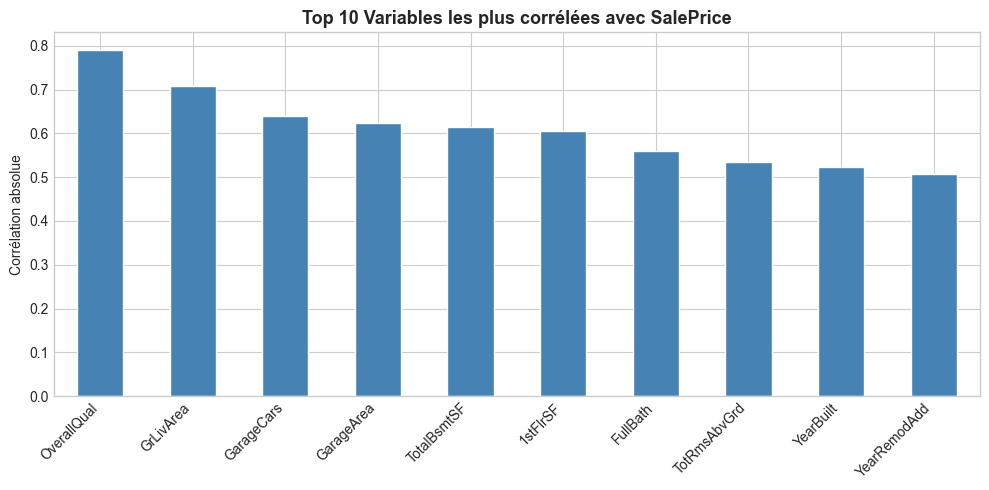

Top 10 corrélations :
OverallQual     0.791
GrLivArea       0.709
GarageCars      0.640
GarageArea      0.623
TotalBsmtSF     0.614
1stFlrSF        0.606
FullBath        0.561
TotRmsAbvGrd    0.534
YearBuilt       0.523
YearRemodAdd    0.507


In [160]:
# Top 10 features les plus corrélées avec SalePrice
corr = train.select_dtypes(include=[np.number]).corr()
top_corr = corr['SalePrice'].abs().sort_values(ascending=False).head(11).drop('SalePrice')

plt.figure(figsize=(10, 5))
top_corr.plot(kind='bar', color='steelblue', edgecolor='white')
plt.title('Top 10 Variables les plus corrélées avec SalePrice', fontsize=13, fontweight='bold')
plt.ylabel('Corrélation absolue')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print('Top 10 corrélations :')
print(top_corr.round(3).to_string())

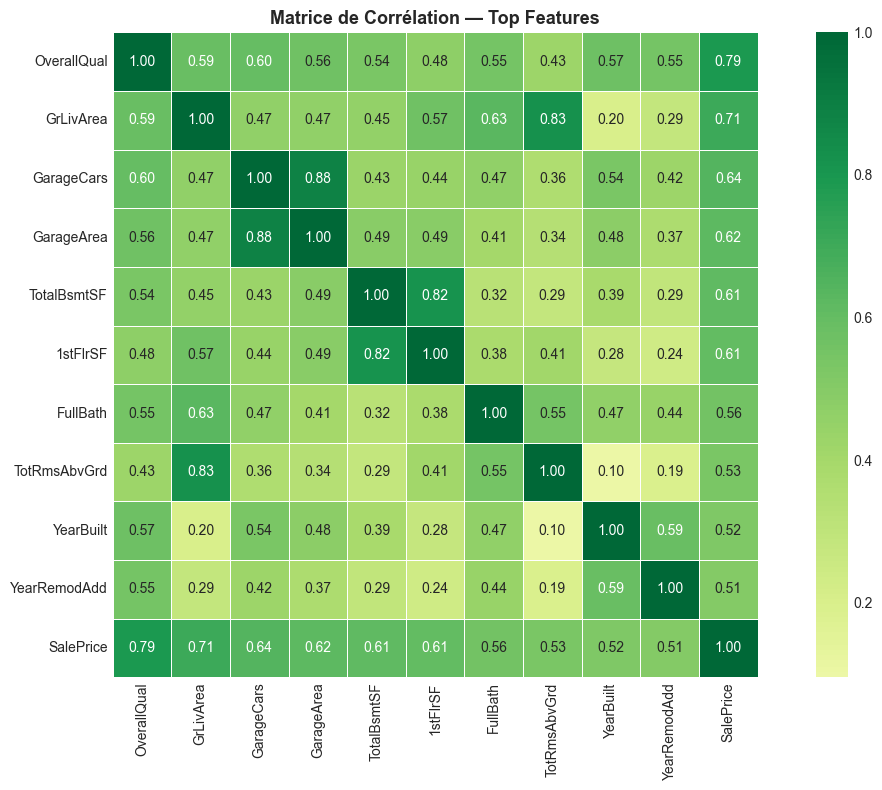

In [161]:
# Heatmap des 10 variables les plus corrélées
top_features = top_corr.index.tolist() + ['SalePrice']
plt.figure(figsize=(12, 8))
sns.heatmap(
    train[top_features].corr(),
    annot=True, fmt='.2f', cmap='RdYlGn',
    center=0, square=True, linewidths=0.5
)
plt.title('Matrice de Corrélation — Top Features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 4. Préparation et nettoyage des données

In [162]:
# Valeurs manquantes dans le train
missing = train.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print(f'{len(missing)} colonnes avec des valeurs manquantes :')
print(missing.head(20))

19 colonnes avec des valeurs manquantes :
PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
BsmtExposure      38
BsmtFinType2      38
BsmtQual          37
BsmtCond          37
BsmtFinType1      37
MasVnrArea         8
Electrical         1
dtype: int64


In [175]:
# ---- Prétraitement ----

# 1. Variable cible : log-transformation
y = np.log(train['SalePrice'])

# 2. Sélection des features numériques uniquement (approche simple et robuste)
num_cols = train.select_dtypes(include=[np.number]).columns.tolist()
num_cols = [c for c in num_cols if c != 'SalePrice' and c != 'Id']

X = train[num_cols].copy()

# 3. Imputation des valeurs manquantes par la médiane
for col in X.columns:
    X[col].fillna(X[col].median(), inplace=True)

print(f'Nombre de features numériques retenues : {X.shape[1]}')
print(f'Valeurs manquantes restantes : {X.isnull().sum().sum()}')

# 4. Split Train / Validation (80% / 20%)
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 5. Normalisation (nécessaire pour Ridge et SVR)
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_val_sc   = scaler.transform(X_val)

print(f'\nTrain : {X_train.shape[0]} | Validation : {X_val.shape[0]}')
print('Préparation des données terminée')

Nombre de features numériques retenues : 36
Valeurs manquantes restantes : 348

Train : 1168 | Validation : 292
Préparation des données terminée


## 5. Entraînement des 4 modèles

In [164]:
# Fonction utilitaire pour afficher les métriques
def evaluate(name, y_true, y_pred, t):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    print(f'\n--- {name} ---')
    print(f'  RMSE : {rmse:.4f}')
    print(f'  MAE  : {mae:.4f}')
    print(f'  R²   : {r2:.4f}')
    print(f'  Temps: {t:.2f}s')
    return rmse, mae, r2, t

In [165]:
# ==============================
# MODÈLE 1 : RIDGE
# ==============================

# Pipeline : imputation + scaling + Ridge
ridge_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="mean")),   # remplace NaN par la moyenne
    ("scaler", StandardScaler()),                  # normalisation
    ("ridge", Ridge(alpha=10.0))                   # modèle Ridge
])

t0 = time.time()
ridge_pipeline.fit(X_train, y_train)   # ici X_train brut avec NaN
t1 = time.time() - t0

m1 = evaluate("Ridge", y_val, ridge_pipeline.predict(X_val), t1)


--- Ridge ---
  RMSE : 0.1518
  MAE  : 0.1088
  R²   : 0.8766
  Temps: 0.01s


In [166]:
# ==============================
# MODÈLE 2 : RANDOM FOREST
# ==============================
t0 = time.time()
rf = RandomForestRegressor(n_estimators=200, max_depth=15,
                            min_samples_split=5, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
t1 = time.time() - t0
m2 = evaluate('Random Forest', y_val, rf.predict(X_val), t1)


--- Random Forest ---
  RMSE : 0.1498
  MAE  : 0.0993
  R²   : 0.8797
  Temps: 0.44s


In [167]:
# ==============================
# MODÈLE 3 : XGBOOST
# ==============================
t0 = time.time()
xgb = XGBRegressor(n_estimators=300, learning_rate=0.05, max_depth=6,
                    subsample=0.8, colsample_bytree=0.8,
                    reg_alpha=0.1, reg_lambda=1.0,
                    random_state=42, verbosity=0)
xgb.fit(X_train, y_train)
t1 = time.time() - t0
m3 = evaluate('XGBoost', y_val, xgb.predict(X_val), t1)


--- XGBoost ---
  RMSE : 0.1421
  MAE  : 0.0939
  R²   : 0.8918
  Temps: 0.62s


In [168]:
# ==============================
# MODÈLE 4 : SVR
# ==============================

from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler

svr_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="mean")),   # remplace NaN par la moyenne
    ("scaler", StandardScaler()),                  # normalisation
    ("svr", SVR(kernel="rbf", C=10.0, epsilon=0.05, gamma="scale"))
])

t0 = time.time()
svr_pipeline.fit(X_train, y_train)   # X_train brut avec NaN
t1 = time.time() - t0

m4 = evaluate("SVR", y_val, svr_pipeline.predict(X_val), t1)


--- SVR ---
  RMSE : 0.1683
  MAE  : 0.1110
  R²   : 0.8483
  Temps: 0.14s


## 6. Étude comparative

In [176]:
# Tableau comparatif
resultats = pd.DataFrame({
    'Modèle'   : ['Ridge', 'Random Forest', 'XGBoost', 'SVR'],
    'RMSE'     : [m1[0], m2[0], m3[0], m4[0]],
    'MAE'      : [m1[1], m2[1], m3[1], m4[1]],
    'R²'       : [m1[2], m2[2], m3[2], m4[2]],
    'Temps (s)': [m1[3], m2[3], m3[3], m4[3]]
}).sort_values('RMSE').reset_index(drop=True)

resultats.index += 1
print('\n=== CLASSEMENT DES MODÈLES ===')
print(resultats.round(4).to_string())
print(f"\n Meilleur modèle : {resultats.iloc[0]['Modèle']}")


=== CLASSEMENT DES MODÈLES ===
          Modèle    RMSE     MAE      R²  Temps (s)
1        XGBoost  0.1421  0.0939  0.8918     0.6244
2  Random Forest  0.1498  0.0993  0.8797     0.4360
3          Ridge  0.1518  0.1088  0.8766     0.0092
4            SVR  0.1683  0.1110  0.8483     0.1363

 Meilleur modèle : XGBoost


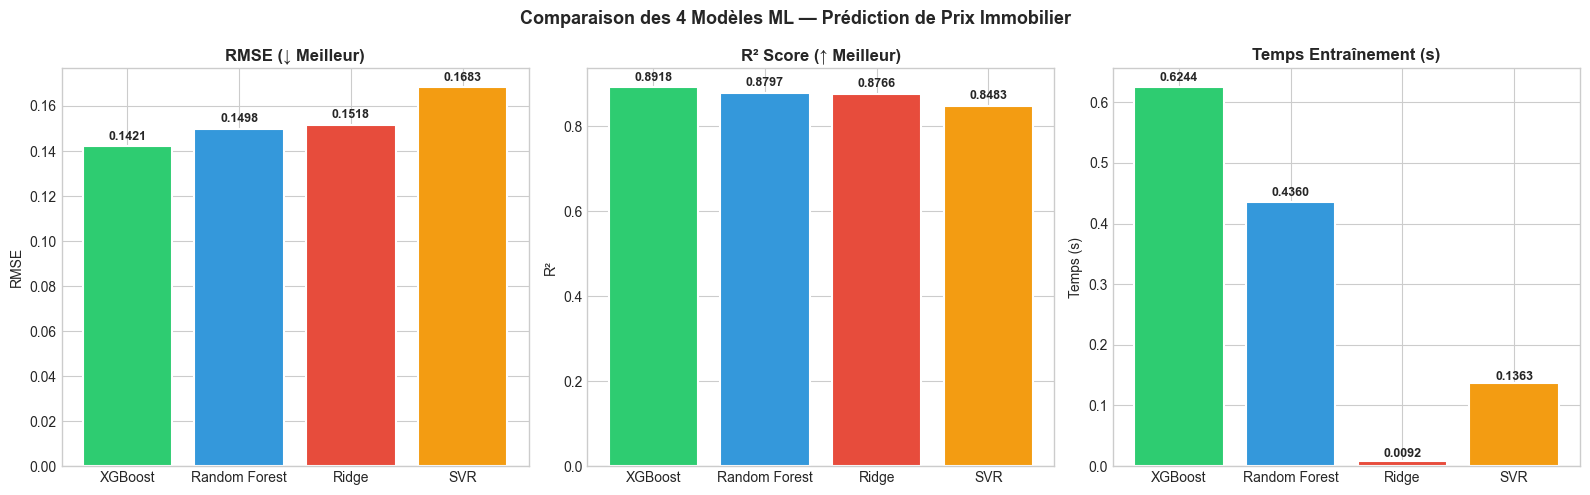

In [170]:
# Graphique 1 : Comparaison RMSE / R² / Temps
colors = ['#2ecc71', '#3498db', '#e74c3c', '#f39c12']
modeles = resultats['Modèle']

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, col, titre, arrow in zip(
    axes,
    ['RMSE', 'R²', 'Temps (s)'],
    ['RMSE (↓ Meilleur)', 'R² Score (↑ Meilleur)', 'Temps Entraînement (s)'],
    ['↓', '↑', '↓']
):
    bars = ax.bar(modeles, resultats[col], color=colors, edgecolor='white', linewidth=1.5)
    ax.set_title(titre, fontsize=12, fontweight='bold')
    ax.set_ylabel(col)
    for bar, val in zip(bars, resultats[col]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.01,
                f'{val:.4f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.suptitle('Comparaison des 4 Modèles ML — Prédiction de Prix Immobilier',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

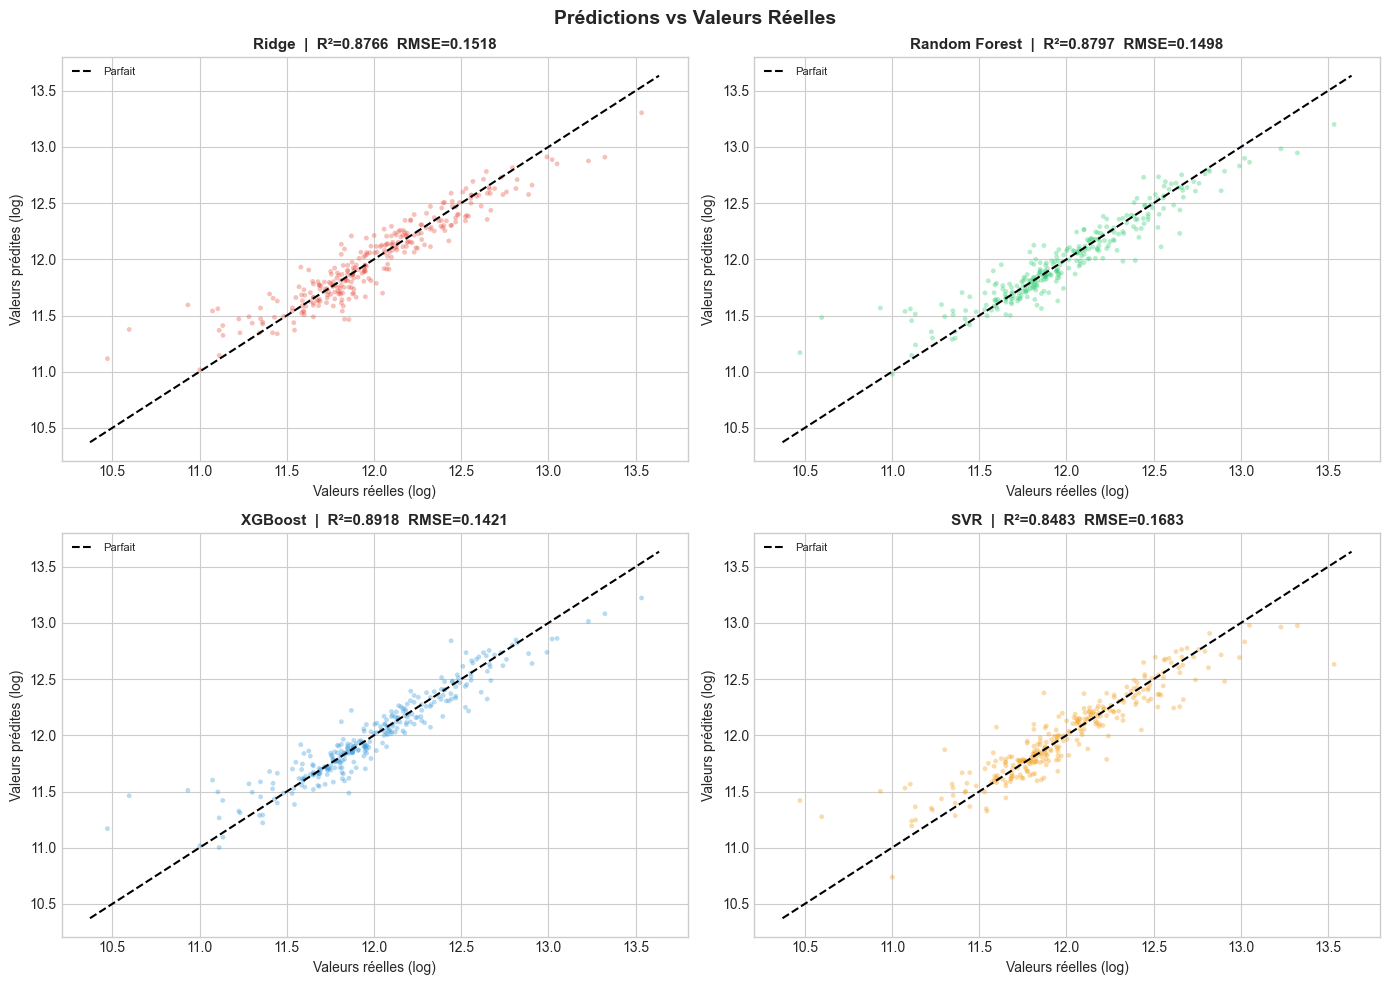

In [171]:
# Graphique 2 : Prédictions vs Valeurs réelles
preds = {
    'Ridge'        : (ridge_pipeline.predict(X_val), '#e74c3c'),
    'Random Forest': (rf.predict(X_val),       '#2ecc71'),
    'XGBoost'      : (xgb.predict(X_val),      '#3498db'),
    'SVR'          : (svr_pipeline.predict(X_val),    '#f39c12'),
}

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, (name, (y_pred, color)) in zip(axes.flatten(), preds.items()):
    r2  = r2_score(y_val, y_pred)
    rmse = np.sqrt(mean_squared_error(y_val, y_pred))
    ax.scatter(y_val, y_pred, alpha=0.35, color=color, s=12, edgecolors='none')
    lims = [min(y_val.min(), y_pred.min()) - 0.1,
            max(y_val.max(), y_pred.max()) + 0.1]
    ax.plot(lims, lims, 'k--', linewidth=1.5, label='Parfait')
    ax.set_xlabel('Valeurs réelles (log)', fontsize=10)
    ax.set_ylabel('Valeurs prédites (log)', fontsize=10)
    ax.set_title(f'{name}  |  R²={r2:.4f}  RMSE={rmse:.4f}',
                 fontsize=11, fontweight='bold')
    ax.legend(fontsize=8)

plt.suptitle('Prédictions vs Valeurs Réelles', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

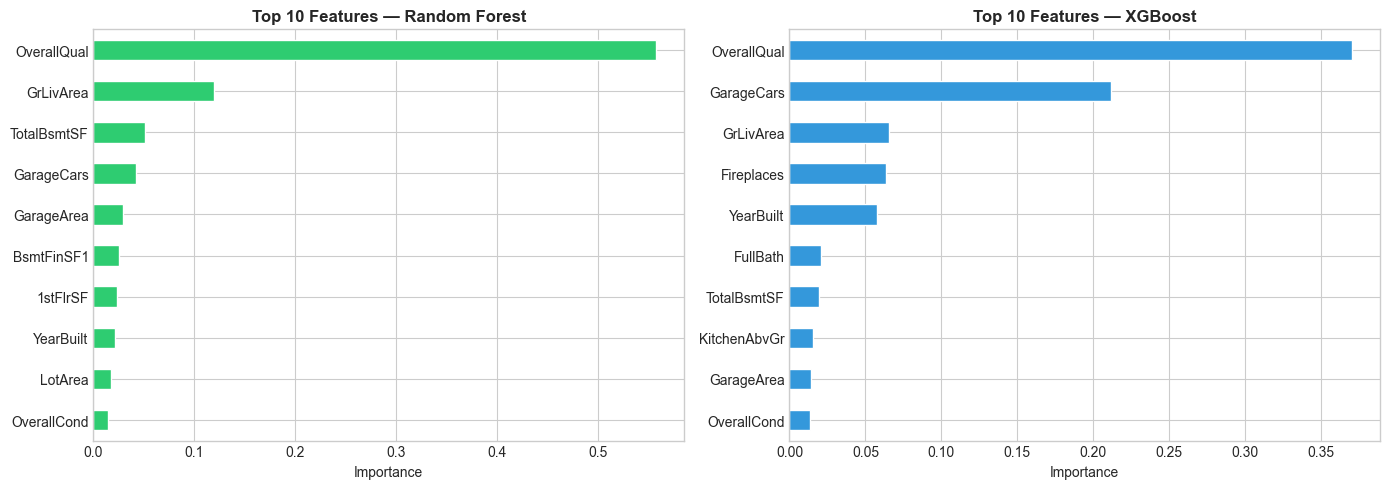

In [172]:
# Graphique 3 : Importance des features (RF + XGBoost)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (model, name, color) in zip(axes, [
    (rf,  'Random Forest', '#2ecc71'),
    (xgb, 'XGBoost',       '#3498db')
]):
    imp = pd.Series(model.feature_importances_, index=X_train.columns)
    imp.nlargest(10).sort_values().plot(kind='barh', ax=ax, color=color, edgecolor='white')
    ax.set_title(f'Top 10 Features — {name}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Importance')

plt.tight_layout()
plt.show()

=== VALIDATION CROISÉE 5-FOLD ===
Ridge           → RMSE moyen : 0.1562 ± 0.0322
Random Forest   → RMSE moyen : 0.1484 ± 0.0150
XGBoost         → RMSE moyen : 0.1366 ± 0.0174
SVR             → RMSE moyen : 0.1600 ± 0.0221


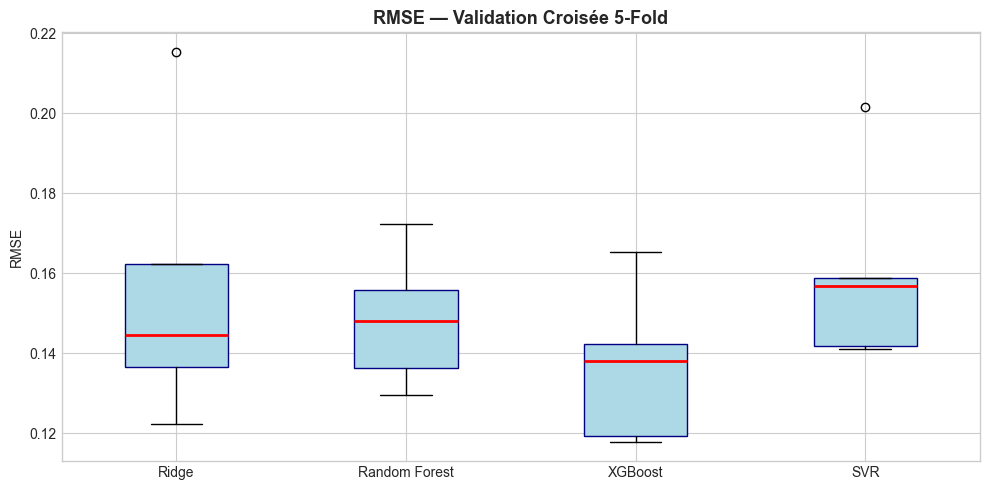

In [173]:
# Validation croisée 5-Fold
print('=== VALIDATION CROISÉE 5-FOLD ===')
kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = {}

for name, model, Xd in [
    ('Ridge',         ridge_pipeline, X_train.values),
    ('Random Forest', rf,             X_train.values),
    ('XGBoost',       xgb,            X_train.values),
    ('SVR',           svr_pipeline,   X_train.values),
]:
    sc = cross_val_score(model, Xd, y_train, cv=kf,
                         scoring='neg_root_mean_squared_error')
    cv_scores[name] = -sc
    print(f'{name:15s} → RMSE moyen : {-sc.mean():.4f} ± {sc.std():.4f}')

# Boxplot CV
plt.figure(figsize=(10, 5))
plt.boxplot(cv_scores.values(), labels=cv_scores.keys(), patch_artist=True,
            boxprops=dict(facecolor='lightblue', color='navy'),
            medianprops=dict(color='red', linewidth=2))
plt.title('RMSE — Validation Croisée 5-Fold', fontsize=13, fontweight='bold')
plt.ylabel('RMSE')
plt.tight_layout()
plt.show()

## 7. Conclusion

| Critère | Ridge | Random Forest | XGBoost | SVR |
|---------|-------|---------------|---------|-----|
| Performance | Moyenne | Très bonne | **Excellente** | Bonne |
| Interprétabilité | Haute | Moyenne | Moyenne | Faible |
| Vitesse | Très rapide | Rapide | Rapide | Lent |
| Non-linéarité | Non | Oui | Oui | Oui |

**Recommandation :** XGBoost offre le meilleur équilibre performance / vitesse pour ce type de données tabulaires.
Ridge reste utile comme baseline interprétable. SVR est adapté aux petits datasets avec outliers.

## Références
1. Breiman, L. (2001). Random Forests. *Machine Learning*, 45(1).
2. Chen & Guestrin (2016). XGBoost. *KDD 2016*.
3. Tibshirani, R. (1996). Lasso/Ridge. *JRSS-B*.
4. Dataset : https://www.kaggle.com/competitions/house-prices-advanced-regression-techniques